# Epilepsy ML Extended Pipeline
**Author (demo):** Saniya Vaish

This notebook demonstrates a reproducible machine learning pipeline aligned with the paper:
**The Use of Machine Learning in Predicting Neurological Disorders for Epilepsy** (see the `papers/` folder).

Goals: Summary of `src/` functionality
- `src.data.loader`: data-loading helpers — prefer the Epileptic Seizure CSV, fall back to curated public biomedical datasets; returns `(DataFrame, metadata)` for downstream steps.
- `src.preprocessing.pipeline`: builds scikit-learn preprocessing pipelines (imputation, scaling, encoding, `adaptive_k_best` feature selection) and exposes reusable transformers.
- `src.preprocessing.eeg_filters`: EEG-specific filters and helpers (bandpass, notch, epoch/window utilities) used prior to feature extraction.
- `src.features.engineer` and `src.features.extractor`: signal and tabular feature construction (statistical summaries, ratios, bandpower, wavelet energies, interactions) and compact feature extractors for modeling.
- `src.models.classical` and `src.models.deep`: model factories and definitions for classical sklearn models (RandomForest, LogisticRegression, etc.) and a small PyTorch MLP, plus helper utilities (e.g., `get_device`, `count_parameters`).
- `src.training.train`: training & evaluation helpers (data splits via `split_data`, `train_sklearn`, `train_torch`, cross-validation helpers like `cross_val_evaluate`, and prediction helpers).
- `src.evaluation.metrics`: evaluation and plotting utilities for classification and clustering (accuracy/F1, sensitivity/specificity, ROC/PR, confusion-matrix plotting, bootstrap CIs).
- `src.visualization.plots`: plotting helpers used across the notebook (class-distribution, correlation matrix, PCA embedding, feature-importance, training-history).
- `src.utils.seed`: reproducibility helpers to set deterministic seeds for experiments and libraries used in the repo.

Each subsequent section in this notebook demonstrates how the `src/` modules are composed to produce reproducible feature engineering, modeling, explainability (SHAP), robust evaluation (CV + bootstrap CIs), and a small 

In [1]:
# Environment and imports
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure repository root is on sys.path so `src` imports work when running the notebook
repo_root = os.path.abspath(os.getcwd())
if repo_root not in sys.path:
    sys.path.append(repo_root)

# Re-use utilities from the repository
from src.data.loader import load_epileptic_seizure, load_public_dataset
from src.preprocessing.pipeline import build_preprocessing_pipeline, adaptive_k_best
from src.features.engineer import enrich_features
from src.models.classical import make_classical_model
from src.training.train import split_data, train_sklearn, cross_val_evaluate
from src.evaluation.metrics import evaluate_model_performance
from src.visualization.plots import (
    plot_class_distribution,
    plot_correlation_matrix,
    plot_pca_embedding,
    plot_feature_importance,
    plot_training_history,
)

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

In [2]:
# Load dataset: prefer epileptic seizure dataset, else fall back to a public biomedical demo dataset
try:
    df, meta = load_epileptic_seizure()
    print('Loaded epileptic seizure dataset.')
except Exception as e:
    print('Epileptic dataset not found locally — using `breast_cancer` demo dataset for reproducibility.')
    df, meta = load_public_dataset('breast_cancer')

print('Dataset metadata:')
print(meta)

# Quick preview
df.head()

Epileptic dataset not found locally — using `breast_cancer` demo dataset for reproducibility.
Dataset metadata:
{'name': 'breast_cancer', 'target_names': [np.str_('malignant'), np.str_('benign')], 'class_names': [np.str_('malignant'), np.str_('benign')], 'feature_names': [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension'), np.str_('radius error'), np.str_('texture error'), np.str_('perimeter error'), np.str_('area error'), np.str_('smoothness error'), np.str_('compactness error'), np.str_('concavity error'), np.str_('concave points error'), np.str_('symmetry error'), np.str_('fractal dimension error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst smoothness'), np.str_('worst compactness'), np.str

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Shape: (569, 31)


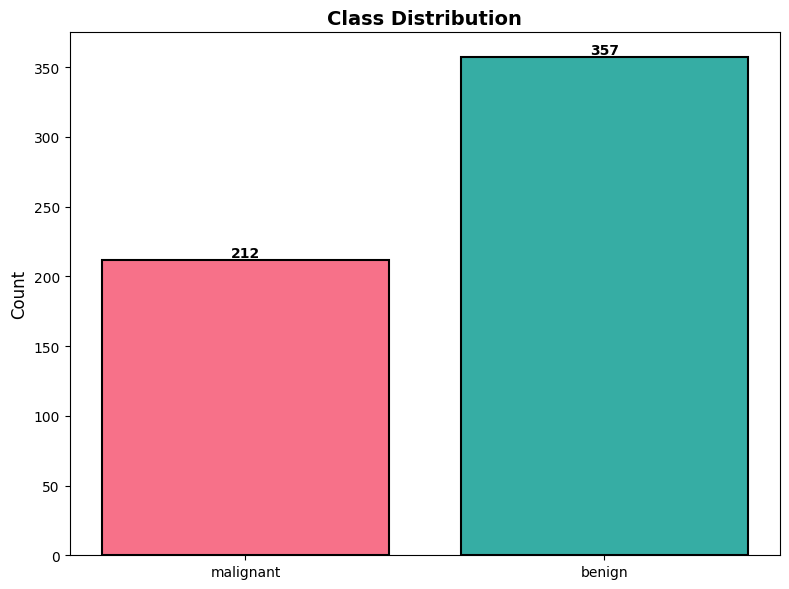

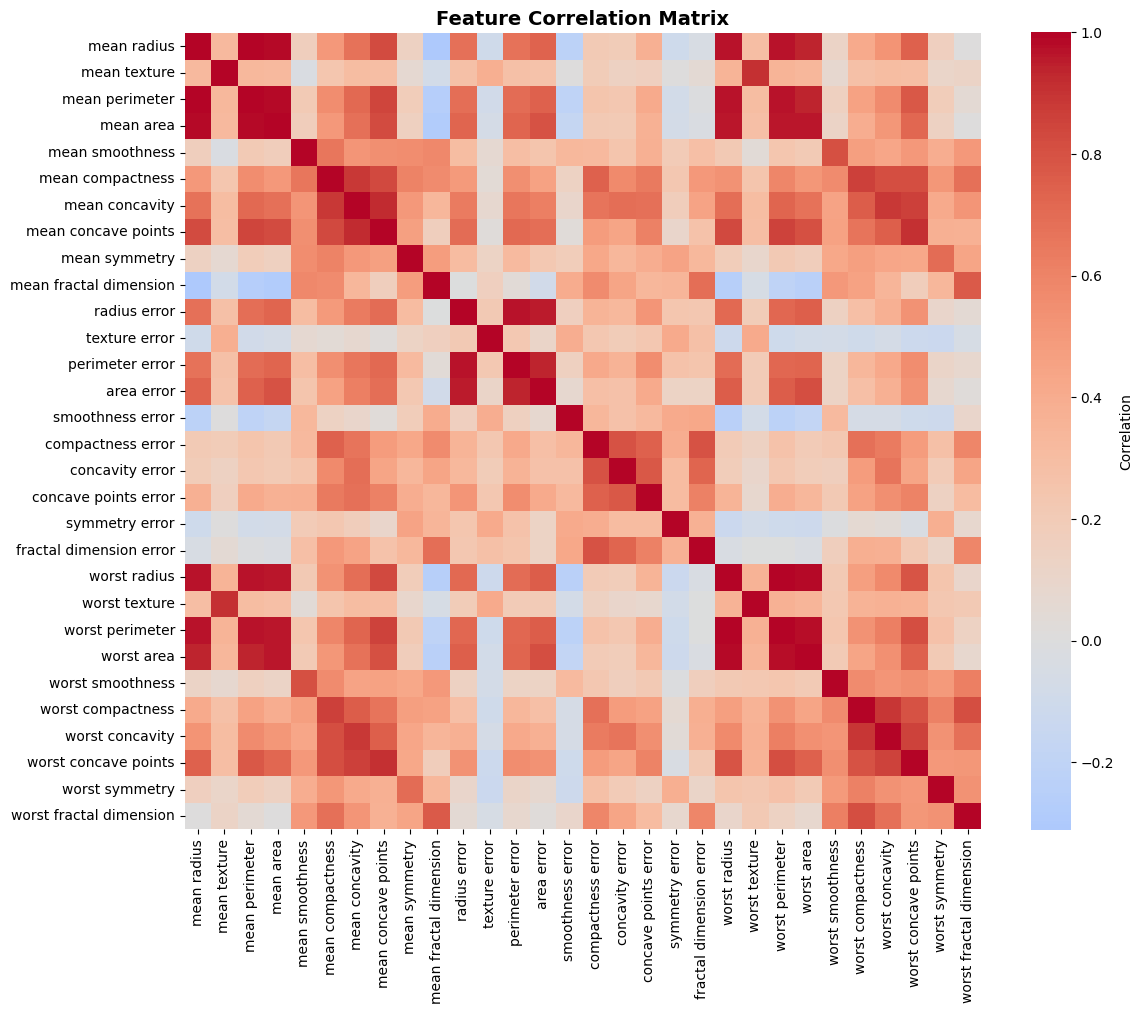

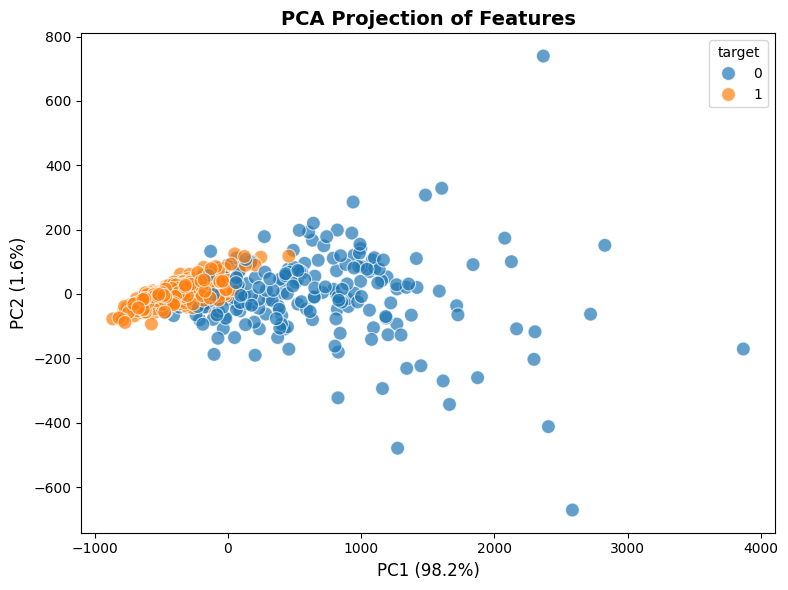

In [3]:
# Basic EDA: shape, class balance, correlations, PCA projection
if 'target' not in df.columns:
    raise RuntimeError(
        'Expected `target` column in the dataframe. Please inspect the loaded CSV.'
    )

print('Shape:', df.shape)

fig = plot_class_distribution(df['target'], labels=meta.get('class_names'))
plt.show()

# Correlation matrix (limit columns to keep plot readable)
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['target'])
fig = plot_correlation_matrix(numeric_df.iloc[:, :min(40, numeric_df.shape[1])])
plt.show()

# PCA projection for a quick view of class separability
fig = plot_pca_embedding(numeric_df.fillna(0).values, df['target'])
plt.show()

In [4]:
# Feature engineering and preprocessing
X = numeric_df.copy()  # raw numeric features (excludes 'target')
y = df['target'].copy()

# Enrich features with statistical / ratio features (fast, deterministic)
X_eng = enrich_features(X, include_statistical=True, include_interactions=False)
print('Engineered features shape:', X_eng.shape)

# Build a preprocessing pipeline (no polynomial expansion here to preserve feature names)
k = min(30, X_eng.shape[1])
preproc = build_preprocessing_pipeline(k_best=k, add_poly=False)

# Split data (train/val/test) and fit pipeline on training data
train_df = pd.concat([X_eng, y], axis=1)
X_train, X_val, X_test, y_train, y_val, y_test = split_data(train_df, target_col='target')

X_train_proc = preproc.fit_transform(X_train, y_train)
X_val_proc = preproc.transform(X_val)
X_test_proc = preproc.transform(X_test)

print('Processed shapes ->', X_train_proc.shape, X_val_proc.shape, X_test_proc.shape)

Engineered features shape: (569, 44)
Processed shapes -> (398, 30) (57, 30) (114, 30)


In [5]:
# Train a classical baseline (Random Forest) and evaluate
model = make_classical_model('random_forest')
model = train_sklearn(model, X_train_proc, y_train)

# Predict and evaluate on test set
y_pred = model.predict(X_test_proc)
y_proba = model.predict_proba(X_test_proc) if hasattr(model, 'predict_proba') else None

evaluate_model_performance(y_test, y_pred, y_proba, name='RandomForest - Baseline')


Model: RandomForest - Baseline

Accuracy:  0.9474
F1-Score:  0.9474
Precision: 0.9474
Recall:    0.9474
MCC:       0.8869

Medical Metrics:
Sensitivity (TPR): 0.9583
Specificity (TNR): 0.9286
PPV:               0.9583
NPV:               0.9286
ROC-AUC:   0.9914

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        42
           1       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



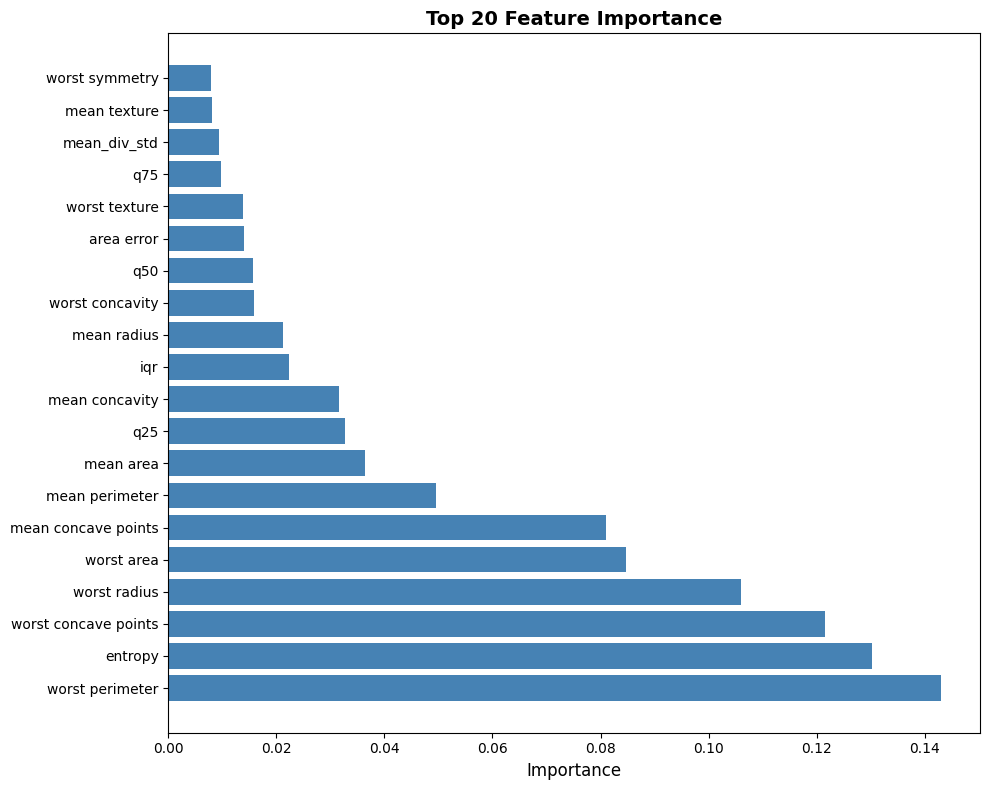

In [6]:
# Feature importance (map back to selected feature names)
if hasattr(model, 'feature_importances_'):
    selector = preproc.named_steps['selector']
    selected_idx = selector.get_support(indices=True)
    feature_names = X_train.columns[selected_idx]
    importances = model.feature_importances_
    fig = plot_feature_importance(feature_names.tolist(), importances, top_n=20)
    plt.show()
else:
    print('Model does not expose `feature_importances_`.')

Using device: cpu
MLP parameters: 12354
Epoch 1/10 - Train Loss: 0.6309, Train Acc: 0.6935 | Val Loss: 0.5178, Val Acc: 0.8947
Epoch 2/10 - Train Loss: 0.4175, Train Acc: 0.9573 | Val Loss: 0.3635, Val Acc: 0.9474
Epoch 3/10 - Train Loss: 0.2577, Train Acc: 0.9472 | Val Loss: 0.2579, Val Acc: 0.9298
Epoch 4/10 - Train Loss: 0.1733, Train Acc: 0.9523 | Val Loss: 0.2087, Val Acc: 0.9474
Epoch 5/10 - Train Loss: 0.1188, Train Acc: 0.9573 | Val Loss: 0.1893, Val Acc: 0.9474
Epoch 6/10 - Train Loss: 0.0913, Train Acc: 0.9724 | Val Loss: 0.1794, Val Acc: 0.9474
Epoch 7/10 - Train Loss: 0.0858, Train Acc: 0.9749 | Val Loss: 0.1712, Val Acc: 0.9474
Epoch 8/10 - Train Loss: 0.0769, Train Acc: 0.9849 | Val Loss: 0.1581, Val Acc: 0.9298
Epoch 9/10 - Train Loss: 0.0638, Train Acc: 0.9824 | Val Loss: 0.1515, Val Acc: 0.9474
Epoch 10/10 - Train Loss: 0.0485, Train Acc: 0.9874 | Val Loss: 0.1489, Val Acc: 0.9474


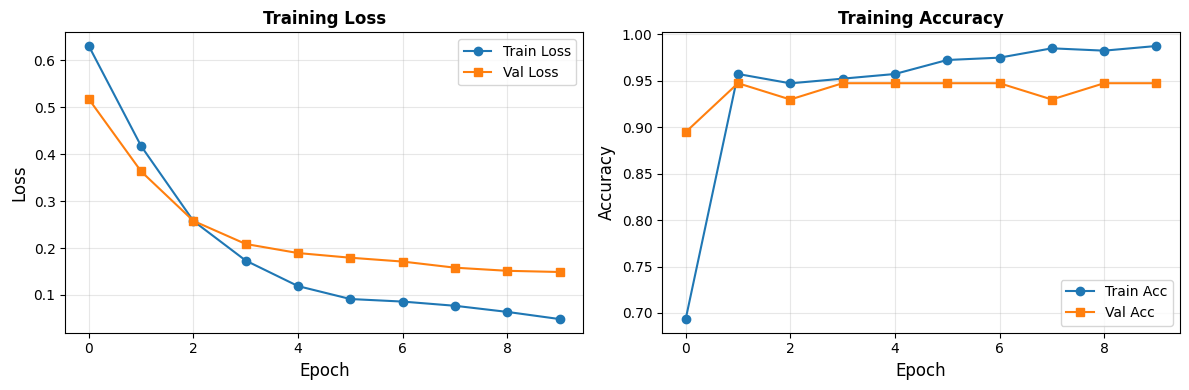


Model: SimpleMLP

Accuracy:  0.9386
F1-Score:  0.9390
Precision: 0.9408
Recall:    0.9386
MCC:       0.8713

Medical Metrics:
Sensitivity (TPR): 0.9306
Specificity (TNR): 0.9524
PPV:               0.9710
NPV:               0.8889
ROC-AUC:   0.9921

              precision    recall  f1-score   support

           0       0.89      0.95      0.92        42
           1       0.97      0.93      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



In [7]:
# Optional: small deep model demo (runs only if PyTorch is available)
try:
    import torch
    from src.models.deep import SimpleMLP, get_device, count_parameters
    from src.training.train import train_torch, predict_torch

    device = get_device()
    print('Using device:', device)

    mlp = SimpleMLP(input_dim=X_train_proc.shape[1], n_classes=len(y.unique()))
    print('MLP parameters:', count_parameters(mlp))

    # Quick training for demonstration (small epochs)
    model_torch, history = train_torch(
        mlp,
        pd.DataFrame(X_train_proc),
        pd.Series(y_train.values),
        pd.DataFrame(X_val_proc),
        pd.Series(y_val.values),
        epochs=10,
        batch_size=64,
        verbose=True,
    )

    fig = plot_training_history(history)
    plt.show()

    preds, proba = predict_torch(model_torch, X_test_proc)
    evaluate_model_performance(y_test, preds, proba, name='SimpleMLP')

except Exception as e:
    print('Skipped PyTorch demo (not available or failed):', e)

## Advanced Feature Engineering

This section demonstrates signal-derived features (bandpower via Welch and optional wavelet energies).
It runs short demos on a subset of the data so the notebook stays responsive.

In [8]:
# Advanced Feature Engineering: bandpower & wavelet examples
try:
    from scipy.signal import welch
except Exception as e:
    print('scipy is required for bandpower demo. Install: pip install scipy')
    raise

try:
    import pywt
    have_pywt = True
except Exception:
    have_pywt = False

# Choose candidate signal columns (assume each row is a time-series across columns)
signal_cols = numeric_df.columns.tolist()[:min(200, numeric_df.shape[1])]
print('Using', len(signal_cols), 'columns as per-sample signal length')

def bandpower_from_row(row, fs=173.61, bands=None):
    if bands is None:
        bands = {'delta':(0.5,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,100)}
    f, Pxx = welch(row.values.astype(float), fs=fs, nperseg=min(256, len(row)))
    out = {}
    for name,(low,high) in bands.items():
        idx = (f >= low) & (f <= high)
        out[f'bandpow_{name}'] = float(np.trapz(Pxx[idx], f[idx])) if idx.any() else 0.0
    return out

# Demo on a subset to keep runtime small
n_demo = min(200, numeric_df.shape[0])
bp_list = []
for _, row in numeric_df.iloc[:n_demo, :len(signal_cols)].iterrows():
    bp_list.append(bandpower_from_row(row))
bp_df = pd.DataFrame(bp_list, index=numeric_df.index[:n_demo])
print('Bandpower demo shape:', bp_df.shape)

if have_pywt:
    def wavelet_feats_from_row(row, wavelet='db4', level=3):
        coeffs = pywt.wavedec(row.values.astype(float), wavelet, level=level)
        feats = {}
        for j, c in enumerate(coeffs):
            feats[f'wavelet_energy_L{j}'] = float(np.sum(np.array(c)**2))
        return feats

    wv_list = []
    for _, row in numeric_df.iloc[:n_demo, :len(signal_cols)].iterrows():
        wv_list.append(wavelet_feats_from_row(row))
    wv_df = pd.DataFrame(wv_list, index=numeric_df.index[:n_demo])
    print('Wavelet demo shape:', wv_df.shape)
else:
    print('pywt not available — skip wavelet demo. Install with `pip install pywt`')

# Combine demo features with existing engineered features for demonstration
demo_features = pd.concat([X_eng.iloc[:n_demo].reset_index(drop=True), bp_df.reset_index(drop=True)], axis=1)
if 'wv_df' in locals():
    demo_features = pd.concat([demo_features, wv_df.reset_index(drop=True)], axis=1)
print('Combined demo features shape:', demo_features.shape)

Using 30 columns as per-sample signal length
Bandpower demo shape: (200, 5)
Wavelet demo shape: (200, 4)
Combined demo features shape: (200, 53)


## Model Explainability (SHAP)

Demonstrate SHAP-based explanations for the trained Random Forest. If `shap` is not installed the cell will print instructions.

Rendering SHAP summary plot (may render inline)


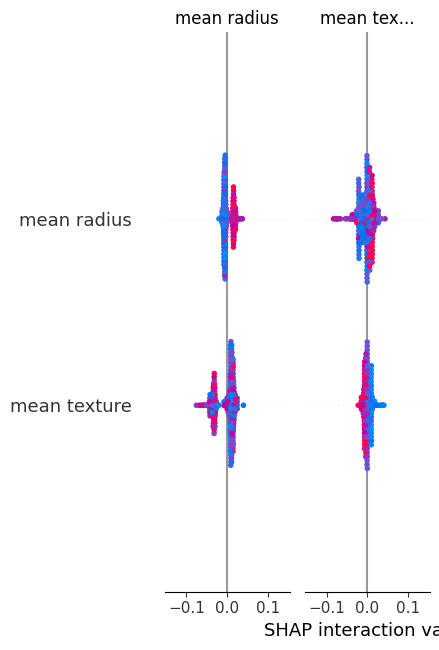

In [9]:
# Model explainability with SHAP (tree models preferred)
try:
    import shap
    have_shap = True
except Exception as e:
    have_shap = False
    print('SHAP not available:', e)

if have_shap:
    try:
        selector = preproc.named_steps.get('selector') if hasattr(preproc, 'named_steps') else None
        if selector is not None:
            selected_idx = selector.get_support(indices=True)
            feat_names = X_train.columns[selected_idx]
        else:
            feat_names = [f'f_{i}' for i in range(X_train_proc.shape[1])]
    except Exception:
        feat_names = [f'f_{i}' for i in range(X_train_proc.shape[1])]

    X_train_df = pd.DataFrame(X_train_proc, columns=feat_names)
    try:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_train_df)
        if isinstance(shap_values, list):
            svals = shap_values[1] if len(shap_values) > 1 else shap_values[0]
        else:
            svals = shap_values
        print('Rendering SHAP summary plot (may render inline)')
        shap.summary_plot(svals, X_train_df, show=False)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print('SHAP TreeExplainer failed:', e)
        try:
            explainer = shap.KernelExplainer(model.predict_proba, shap.kmeans(X_train_df, 10))
            shap_vals = explainer.shap_values(X_train_df.iloc[:50], nsamples=100)
            shap.summary_plot(shap_vals, X_train_df.iloc[:50], show=False)
            plt.show()
        except Exception as e2:
            print('KernelExplainer also failed:', e2)
else:
    print('Install shap (`pip install shap`) to run model explainability examples.')

## Robust Evaluation

Run stratified cross-validation, show a calibration plot (binary only), and produce bootstrap CIs for test metrics.

CV results (mean):
test_accuracy    0.954810
test_f1          0.951603
test_roc_auc     0.992601
dtype: float64


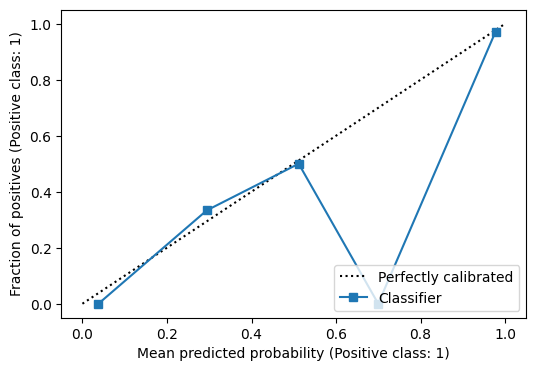

Test accuracy: 0.9474, 95% CI: (np.float64(0.9035087719298246), np.float64(0.9824561403508771))
Test F1 (weighted): 0.9474, 95% CI: (np.float64(0.9041743213316737), np.float64(0.9824561403508771))


In [10]:
# Robust evaluation: stratified CV, calibration curve, and bootstrap CIs
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, f1_score
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {'accuracy':'accuracy', 'f1':'f1_macro'}
if len(np.unique(y_train)) == 2:
    scoring['roc_auc'] = 'roc_auc'

cv_res = cross_validate(model, X_train_proc, y_train, cv=skf, scoring=scoring, return_train_score=False)
import pandas as _pd
print('CV results (mean):')
print(_pd.DataFrame(cv_res).mean()[[k for k in cv_res.keys() if k.startswith('test_')]])

# Calibration plot (binary only)
try:
    from sklearn.calibration import CalibrationDisplay
    if hasattr(model, 'predict_proba') and len(np.unique(y_train)) == 2:
        prob_pos = model.predict_proba(X_val_proc)[:,1]
        fig, ax = plt.subplots(figsize=(6,4))
        CalibrationDisplay.from_predictions(y_val, prob_pos, ax=ax)
        plt.show()
    else:
        print('Calibration plot skipped (requires binary classifier with `predict_proba`).')
except Exception as e:
    print('Calibration skipped:', e)

# Bootstrap confidence intervals for test accuracy and F1
def bootstrap_ci(y_true, y_pred, metric_func, n_boot=1000, alpha=0.05):
    vals = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = np.random.randint(0, n, n)
        vals.append(metric_func(np.array(y_true)[idx], np.array(y_pred)[idx]))
    lower = np.percentile(vals, 100 * (alpha/2))
    upper = np.percentile(vals, 100 * (1 - alpha/2))
    return lower, upper

acc_ci = bootstrap_ci(y_test, y_pred, accuracy_score, n_boot=500)
f1_ci = bootstrap_ci(y_test, y_pred, lambda a,b: f1_score(a,b, average='weighted'), n_boot=500)
print(f'Test accuracy: {accuracy_score(y_test, y_pred):.4f}, 95% CI: {acc_ci}')
print(f'Test F1 (weighted): {f1_score(y_test, y_pred, average="weighted"):.4f}, 95% CI: {f1_ci}')

## Interactive Demo (Gradio)

A small in-notebook Gradio interface lets reviewers try predictions on test samples. Gradio must be installed to run this cell.

In [11]:
# Interactive demo with Gradio (runs a small local interface). Falls back with instructions if Gradio missing.
try:
    import gradio as gr
    def demo_predict(sample_index=0):
        sample_index = int(sample_index)
        if sample_index < 0 or sample_index >= X_test_proc.shape[0]:
            return {'error': 'sample_index out of range'}
        x = X_test_proc[sample_index].reshape(1, -1)
        pred = int(model.predict(x)[0])
        proba = model.predict_proba(x)[0].tolist() if hasattr(model, 'predict_proba') else []
        return {'prediction': int(pred), 'probabilities': proba}

    iface = gr.Interface(fn=demo_predict, inputs=gr.Number(label='Test sample index', value=0), outputs=[gr.JSON(label='Result')], title='Model demo')
    print('Launching Gradio demo — this will block the notebook kernel until stopped. Use share=False to avoid public URL.')
    iface.launch(share=False)
except Exception as e:
    print('Gradio not available or failed to launch:', e)
    print('Install with `pip install gradio` and re-run this cell to launch the demo.')

Launching Gradio demo — this will block the notebook kernel until stopped. Use share=False to avoid public URL.
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


## Conclusion & Reproducibility
This notebook follows the pipeline described in the associated paper and demonstrates:
- Reproducible data loading using `src.data.loader` (prefers the Epileptic Seizure dataset)
- Feature engineering and a lightweight preprocessing pipeline
- A classical baseline (Random Forest) with evaluation metrics used in medical ML
- An optional quick deep-learning demo if PyTorch is available

To reproduce locally:
1. Create a Python environment and install requirements: `pip install -r requirements.txt`
2. Start Jupyter in the repository root and open this notebook: `jupyter lab` or `jupyter notebook`
3. If you want to use the Epileptic Seizure dataset, place the CSV at `data/epileptic_seizure.csv` (the loader will pick it up).

References:
- Vaish, S. (2024). The Use of Machine Learning in Predicting Neurological Disorders for Epilepsy. See `papers/` folder for the PDF and metadata.